In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
from matplotlib.colors import ListedColormap

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
linkages_df = pd.read_csv("01A_confident_linkages_per_cell_type.csv", index_col = 0)

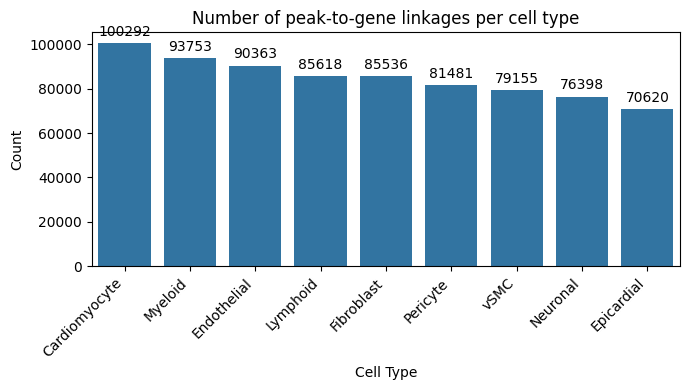

In [4]:
# Group by cell type and count
cell_counts = linkages_df.groupby("CellType").size().reset_index(name="count")

# Sort by count (optional, for nicer plot)
cell_counts = cell_counts.sort_values("count", ascending=False)

# Plot
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=cell_counts, x="CellType", y="count", color="#1f77b4")  # blue, change hex as desired

# Add count labels above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), 
        textcoords='offset points'
    )

plt.xticks(rotation=45, ha="right")
plt.title("Number of peak-to-gene linkages per cell type")
plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("01B_number_of_scE2G_linkages_per_cell_type.pdf")
plt.show()

### Visualize these linkages by showing them in terms of intersected peaks

In [5]:
revised_linkages_df = linkages_df.rename(
    columns = {"chr": "Chromosome",
              "start": "Start",
              "end": "End"})

In [6]:
gr = pr.PyRanges(revised_linkages_df)
# merge overlapping regions (by chromosome)
merged_gr = gr.merge()

# back to dataframe
merged_df = merged_gr.as_df()

In [7]:
merged_df["region_id"] = merged_df["Chromosome"].astype(str) + ":" + \
                         merged_df["Start"].astype(str) + "-" + \
                         merged_df["End"].astype(str)

# For overlap between original linkages_df and merged_df
gr_merged = pr.PyRanges(merged_df)
gr_orig = pr.PyRanges(revised_linkages_df[["Chromosome","Start","End","CellType"]])

# Map cell types to merged regions
overlaps = gr_merged.join(gr_orig).as_df()

# Pivot into matrix
region_celltype = overlaps.pivot_table(
    index="region_id",
    columns="CellType",
    values="Chromosome",
    aggfunc="count",
    fill_value=0
)

In [8]:
region_celltype.shape

(183550, 9)

In [9]:
n_sample = min(1000, region_celltype.shape[0])
region_celltype_sub = region_celltype.sample(n=n_sample, random_state=0)

In [10]:
# binarize
bin_region_celltype_bin = (region_celltype_sub > 0).astype(int)

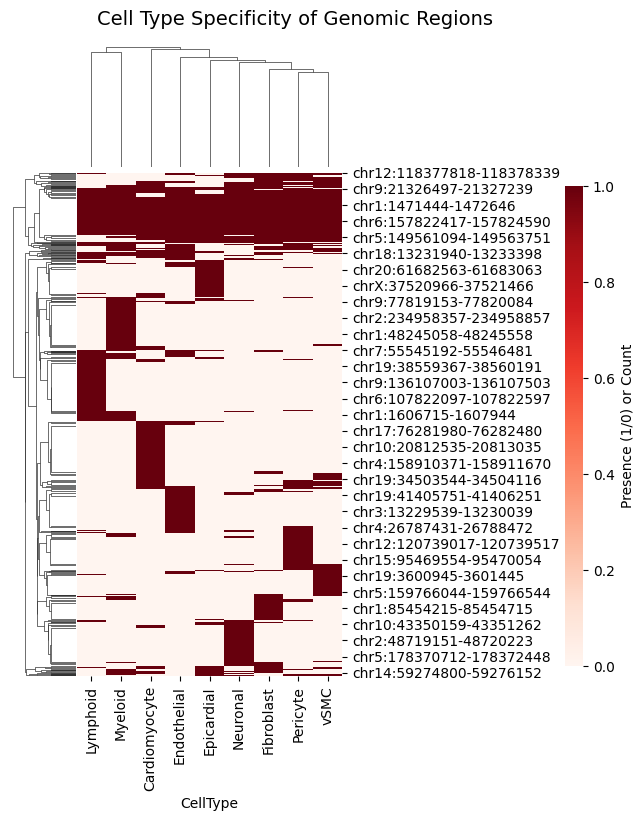

In [11]:
sns.clustermap(
    bin_region_celltype_bin,
    cmap="Reds",   # or "Reds", "coolwarm", etc.
    method="average", # linkage method: "single", "complete", "average", "ward"
    metric="euclidean", # distance metric: "euclidean", "cosine", etc.
    cbar_kws={"label": "Presence (1/0) or Count"},
    figsize=(6, 8),
    cbar_pos=(0.95, 0.2, 0.03, 0.6)
)

plt.suptitle("Cell Type Specificity of Genomic Regions", fontsize=14, y=1.02)
plt.savefig("01B_binarized_scE2G_linkages.pdf")
plt.show()